<a href="https://colab.research.google.com/github/Archangel4148/STAT-4210-Final-Project/blob/master/Final_Lasso_Ridge_Linear_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=862324b605429776021a7dec74edf2db3e20a1888ae0796e82caa48c0e13f2dc
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
path='/content/drive/MyDrive/Colab Notebooks/'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [5]:
import statsmodels.api as sm

In [6]:
from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [7]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

In [8]:
StudentDepression = load_data("/content/drive/MyDrive/Colab Notebooks/Student Depression Dataset")
StudentDepression.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

#Ordinary Least Squares Mulitiple Linear Regression

In [9]:
terms = StudentDepression.columns.drop(['Depression', 'City', 'id', 'Gender', 'Profession', 'Degree'])
terms

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness'],
      dtype='object')

In [12]:
terms = StudentDepression.columns.drop(['Depression', 'City', 'id', 'Gender', 'Profession', 'Degree'])

object_cols_in_terms = [col for col in terms if StudentDepression[col].dtype == 'object']

StudentDepression_processed = StudentDepression.copy()
for col in object_cols_in_terms:
    StudentDepression_processed[col] = StudentDepression_processed[col].astype('category')

StudentDepression_processed = StudentDepression_processed[
    (StudentDepression_processed['Sleep Duration'] != 'Others') &
    (StudentDepression_processed['Dietary Habits'] != 'Others')
]

StudentDepression_processed['Sleep Duration'] = StudentDepression_processed['Sleep Duration'].cat.remove_unused_categories()
StudentDepression_processed['Dietary Habits'] = StudentDepression_processed['Dietary Habits'].cat.remove_unused_categories()

StudentDepression_processed = StudentDepression_processed.dropna()

y = StudentDepression_processed['Depression']
X = MS(terms).fit_transform(StudentDepression_processed)

model = sm.OLS(y, X)
results = model.fit()

In [13]:
StudentDepression['Dietary Habits'].unique()

array(['Healthy', 'Moderate', 'Unhealthy', 'Others'], dtype=object)

In [14]:
StudentDepression['Sleep Duration'].unique()

array(['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours',
       'Others'], dtype=object)

###Ordinary Least Squares Regression Coefficients

In [15]:
# Identify object columns in the StudentDepression DataFrame that are in 'terms'
object_cols_in_terms = [col for col in terms if StudentDepression[col].dtype == 'object']

# Create a copy of the DataFrame and convert identified object columns to 'category' dtype
StudentDepression_processed = StudentDepression.copy()
for col in object_cols_in_terms:
    StudentDepression_processed[col] = StudentDepression_processed[col].astype('category')

# Filter out 'Others' from 'Sleep Duration' and 'Dietary Habits'
StudentDepression_processed = StudentDepression_processed[
    (StudentDepression_processed['Sleep Duration'] != 'Others') &
    (StudentDepression_processed['Dietary Habits'] != 'Others')
]

# Remove unused categories after filtering
StudentDepression_processed['Sleep Duration'] = StudentDepression_processed['Sleep Duration'].cat.remove_unused_categories()
StudentDepression_processed['Dietary Habits'] = StudentDepression_processed['Dietary Habits'].cat.remove_unused_categories()

# Drop rows with any missing values from the processed DataFrame
StudentDepression_processed = StudentDepression_processed.dropna()

# Ensure 'y' aligns with the processed DataFrame after dropping NaNs
y = StudentDepression_processed['Depression']

# Now apply ModelSpec to the processed dataframe
X = MS(terms).fit_transform(StudentDepression_processed)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-0.0357,0.019,-1.861,0.063
Age,-0.0132,0.000,-31.184,0.000
Academic Pressure,0.1087,0.002,69.612,0.000
Work Pressure,0.0282,0.073,0.385,0.700
CGPA,0.0071,0.001,5.073,0.000
Study Satisfaction,-0.0292,0.002,-19.182,0.000
Job Satisfaction,0.0297,0.072,0.410,0.682
Sleep Duration[7-8 hours],0.0045,0.006,0.757,0.449
Sleep Duration[Less than 5 hours],0.0404,0.006,7.017,0.000
Sleep Duration[More than 8 hours],-0.0318,0.006,-5.126,0.000


###Ordinary Least Squares Significant Coefficients

In [16]:
terms = StudentDepression.columns.drop(['Depression', 'Job Satisfaction', 'City', 'id', 'Gender', 'Profession', 'Degree', 'Work Pressure'])

In [17]:
object_cols_in_terms = [col for col in terms if StudentDepression[col].dtype == 'object']

StudentDepression_processed = StudentDepression.copy()
for col in object_cols_in_terms:
    StudentDepression_processed[col] = StudentDepression_processed[col].astype('category')

# Filter out 'Others' from 'Sleep Duration' and 'Dietary Habits'
StudentDepression_processed = StudentDepression_processed[
    (StudentDepression_processed['Sleep Duration'] != 'Others') &
    (StudentDepression_processed['Dietary Habits'] != 'Others')
]

# Remove unused categories after filtering
StudentDepression_processed['Sleep Duration'] = StudentDepression_processed['Sleep Duration'].cat.remove_unused_categories()
StudentDepression_processed['Dietary Habits'] = StudentDepression_processed['Dietary Habits'].cat.remove_unused_categories()

StudentDepression_processed = StudentDepression_processed.dropna()

y = StudentDepression_processed['Depression']

X = MS(terms).fit_transform(StudentDepression_processed)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-0.0346,0.019,-1.807,0.071
Age,-0.0132,0.000,-31.185,0.000
Academic Pressure,0.1086,0.002,69.609,0.000
CGPA,0.0070,0.001,5.014,0.000
Study Satisfaction,-0.0293,0.002,-19.223,0.000
Sleep Duration[7-8 hours],0.0045,0.006,0.760,0.447
Sleep Duration[Less than 5 hours],0.0404,0.006,7.013,0.000
Sleep Duration[More than 8 hours],-0.0318,0.006,-5.133,0.000
Dietary Habits[Moderate],0.0617,0.005,11.819,0.000
Dietary Habits[Unhealthy],0.1319,0.005,25.248,0.000


### 95% Confidence Intervals for Coefficients

In [18]:
print('OLS Regression Coefficients 95% Confidence Intervals:')
display(results.conf_int(alpha=0.05))

OLS Regression Coefficients 95% Confidence Intervals:


,0,1
intercept,-0.072109,0.002934
Age,-0.014012,-0.012355
Academic Pressure,0.105569,0.111686
CGPA,0.004265,0.009741
Study Satisfaction,-0.032239,-0.026273
Sleep Duration[7-8 hours],-0.007098,0.016083
Sleep Duration[Less than 5 hours],0.029097,0.051668
Sleep Duration[More than 8 hours],-0.044001,-0.019684
Dietary Habits[Moderate],0.051456,0.071916
Dietary Habits[Unhealthy],0.121615,0.142087


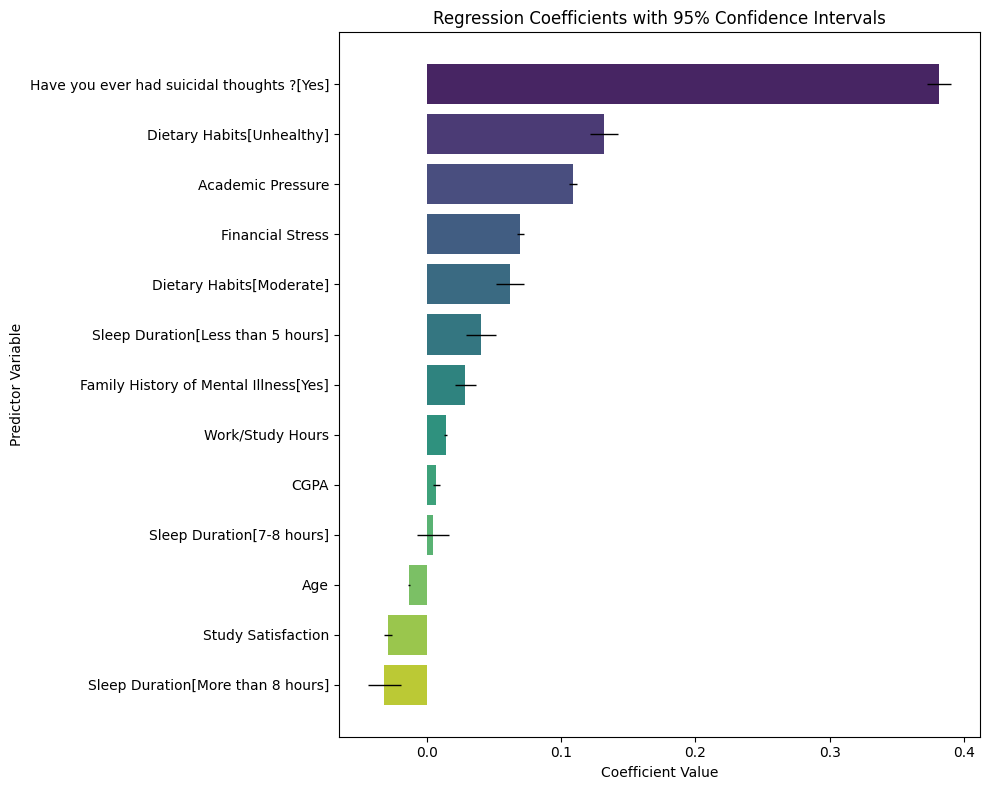

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the coefficients and their confidence intervals
coefs = results.params
conf_int = results.conf_int(alpha=0.05)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'predictor': coefs.index,
    'coefficient': coefs.values,
    'lower_ci': conf_int.iloc[:, 0],
    'upper_ci': conf_int.iloc[:, 1]
})

# Exclude the intercept from the plot for better visualization of predictors
coef_df = coef_df[coef_df['predictor'] != 'intercept']

# Sort by coefficient value for better readability
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='coefficient', y='predictor', data=coef_df, palette='viridis', hue='predictor', legend=False, ax=ax)

# Add error bars for confidence intervals
for idx, row in coef_df.iterrows():
    ax.hlines(row['predictor'], row['lower_ci'], row['upper_ci'], color='black', linewidth=1)

ax.set_title('Regression Coefficients with 95% Confidence Intervals')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Predictor Variable')
plt.tight_layout()
plt.show()

### 95% Prediction Intervals for Coefficients

Sample of OLS Predictions with 95% Prediction Intervals:


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,0.571156,0.008789,0.553929,0.588382,-0.100045,1.242357
1,0.033116,0.007683,0.018057,0.048175,-0.638032,0.704265
2,0.051110,0.007524,0.036363,0.065858,-0.620031,0.722252
3,0.783467,0.007341,0.769078,0.797856,0.112333,1.454601
4,0.566326,0.007746,0.551144,0.581507,-0.104826,1.237477


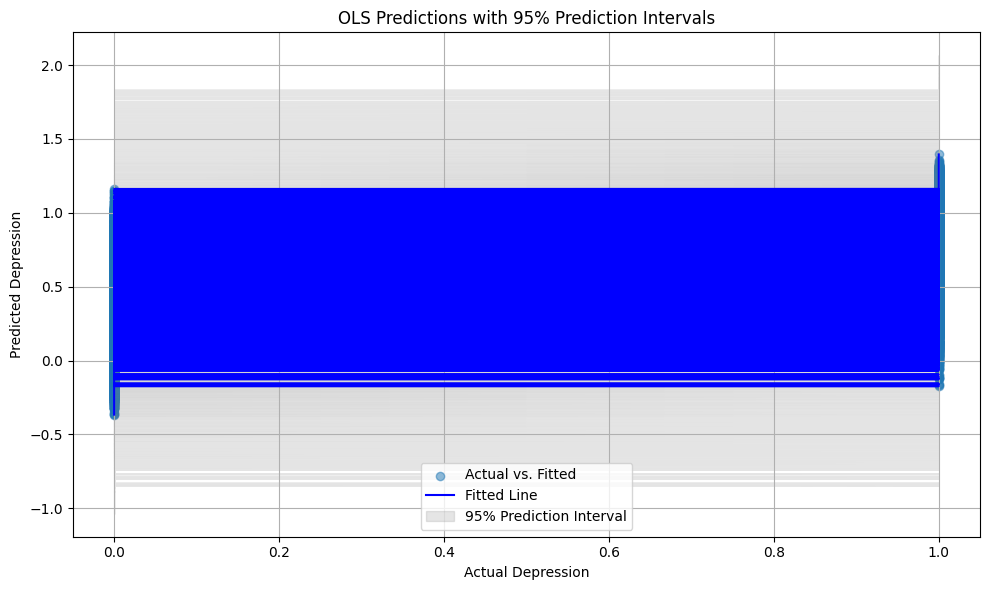

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions and prediction intervals for the OLS model
predictions_summary_frame = results.get_prediction(X).summary_frame(alpha=0.05)

# Display a sample of the prediction intervals
print("Sample of OLS Predictions with 95% Prediction Intervals:")
display(predictions_summary_frame.head())

# You can also visualize these if desired, for example, on a scatter plot of observed vs. fitted values
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y, results.fittedvalues, alpha=0.5, label='Actual vs. Fitted')

# Plot prediction intervals for a subset of the data for clarity
# For better visualization, we might sort by fitted values or use a more sophisticated plot
ordered_indices = np.argsort(results.fittedvalues)

ax.plot(y.iloc[ordered_indices], predictions_summary_frame['mean'].iloc[ordered_indices], color='blue', label='Fitted Line')
ax.fill_between(y.iloc[ordered_indices],
                predictions_summary_frame['obs_ci_lower'].iloc[ordered_indices],
                predictions_summary_frame['obs_ci_upper'].iloc[ordered_indices],
                color='gray', alpha=0.2, label='95% Prediction Interval')

ax.set_xlabel('Actual Depression')
ax.set_ylabel('Predicted Depression')
ax.set_title('OLS Predictions with 95% Prediction Intervals')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Varinace Inflation Factor (VIF)

In [21]:
vif = pd.DataFrame({'predictor': X.columns, 'VIF': [VIF(X.values, i) for i in range(X.shape[1])]})
display(vif)

,predictor,VIF
0,intercept,87.145693
1,Age,1.022766
2,Academic Pressure,1.105429
3,CGPA,1.003364
4,Study Satisfaction,1.020297
5,Sleep Duration[7-8 hours],1.613631
6,Sleep Duration[Less than 5 hours],1.649234
7,Sleep Duration[More than 8 hours],1.554041
8,Dietary Habits[Moderate],1.484706
9,Dietary Habits[Unhealthy],1.511552


### Residual Analysis

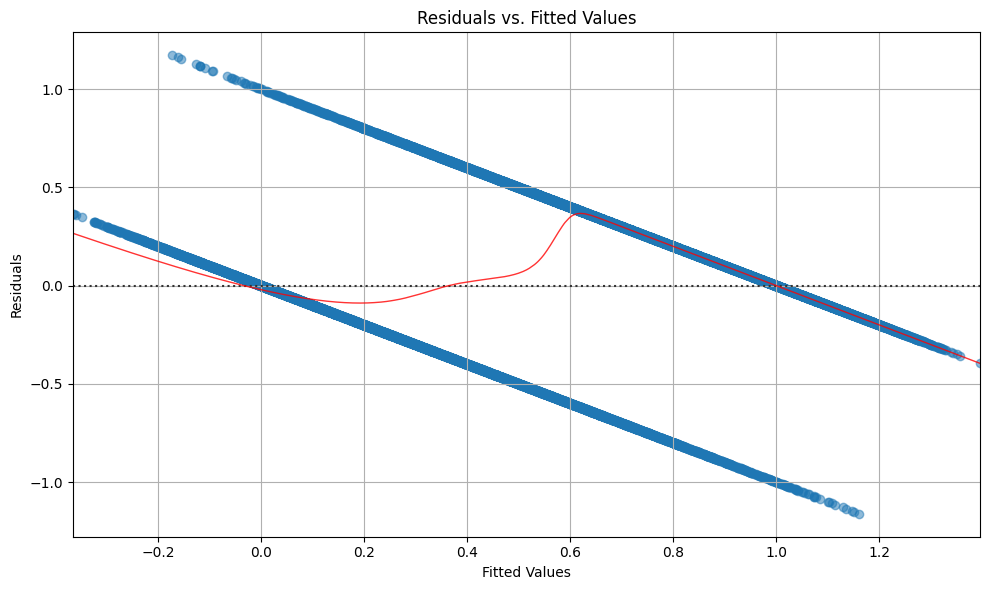

In [22]:
# Plotting residuals vs. fitted values
fig, ax = plt.subplots(figsize=(10, 6))
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, ax=ax,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
ax.set_title('Residuals vs. Fitted Values')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.grid(True)
plt.tight_layout()
plt.show()

###Robust Covariance Estimation

In [23]:
results_robust = results.get_robustcov_results(cov_type='HC3')
print(results_robust.summary())

                            OLS Regression Results                            
Dep. Variable:             Depression   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     4887.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:40:28   Log-Likelihood:                -9661.9
No. Observations:               27868   AIC:                         1.935e+04
Df Residuals:                   27854   BIC:                         1.947e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

###Q-Q Plot

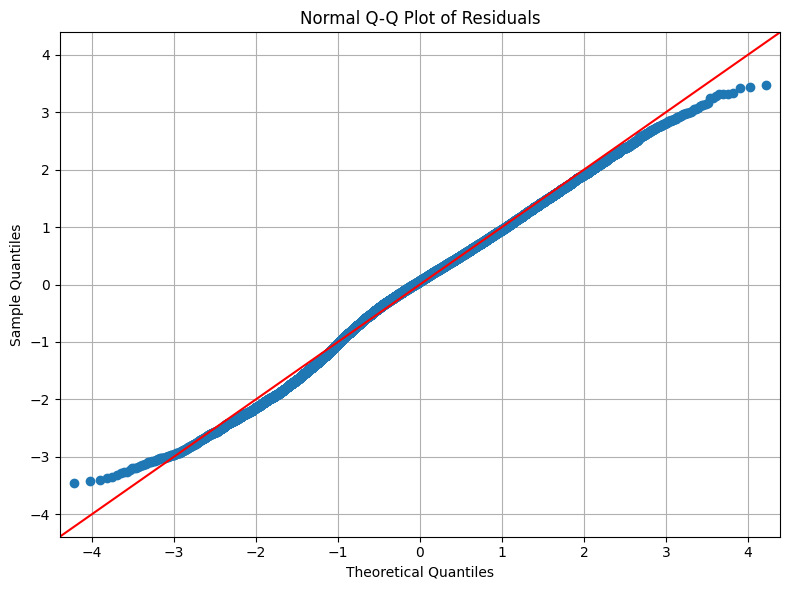

In [24]:
import statsmodels.api as sm
import scipy.stats as stats

# Q-Q plot of standardized residuals
fig, ax = plt.subplots(figsize=(8, 6))
res = results.resid # residuals
probplot = sm.ProbPlot(res, stats.t, fit=True)
probplot.qqplot(line='45', ax=ax)
ax.set_title('Normal Q-Q Plot of Residuals')
ax.grid(True)
plt.tight_layout()
plt.show()

###Cross-Validation

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the OLS model on the training data
ols_model_cv = sm.OLS(y_train, X_train)
ols_results_cv = ols_model_cv.fit()

# Make predictions on the test set
ols_predictions_test = ols_results_cv.predict(X_test)

# Evaluate the model on the test set
ols_mse_cv = mean_squared_error(y_test, ols_predictions_test)
ols_rmse_cv = np.sqrt(ols_mse_cv)
ols_mae_cv = mean_absolute_error(y_test, ols_predictions_test)
ols_r2_cv = r2_score(y_test, ols_predictions_test)

# Display the evaluation metrics
print(f"OLS Model Cross-Validation Metrics (Test Set):\n")
print(f"  R-squared: {ols_r2_cv:.4f}")
print(f"  Mean Squared Error (MSE): {ols_mse_cv:.4f}")
print(f"  Root Mean Squared Error (RMSE): {ols_rmse_cv:.4f}")
print(f"  Mean Absolute Error (MAE): {ols_mae_cv:.4f}")

OLS Model Cross-Validation Metrics (Test Set):

  R-squared: 0.5211
  Mean Squared Error (MSE): 0.1158
  Root Mean Squared Error (RMSE): 0.3404
  Mean Absolute Error (MAE): 0.2656


# Ridge Regression

In [26]:
import sklearn.linear_model as skl
import numpy as np

# Drop the intercept column before scaling the features
X_for_elasticnet = X.drop(columns=['intercept'])

# Center and scale the features
Xs = X_for_elasticnet - X_for_elasticnet.mean(0).to_numpy()[None,:]
X_scale = X_for_elasticnet.std(0).to_numpy()

# Handle potential division by zero if a feature has zero standard deviation
X_scale[X_scale == 0] = 1

Xs = Xs / X_scale[None,:]

lambdas = 10**np.linspace(8, -2, 100) / y.std()
soln_array = skl.ElasticNet.path(Xs,
                                 y,
                                 l1_ratio=0.,
                                 alphas=lambdas
                                 )[1]
print(soln_array.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8158.999986120409, tolerance: 1.6318000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did

(13, 100)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6437.8223319732015, tolerance: 1.6318000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di

In [27]:
from sklearn.linear_model import RidgeCV

# Define a range of alpha values (lambdas) for RidgeCV to search over.
# It's good practice to use a logarithmic scale for alpha.
# The `lambdas` array from before can be used, or a new one can be generated.
alphas = 10**np.linspace(-2, 8, 100) # scikit-learn uses alpha instead of lambda

# Initialize RidgeCV model. cv=None uses Leave-One-Out Cross-Validation by default.
# We set store_cv_results=True to inspect the mean squared errors for each alpha.
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True, scoring='neg_mean_squared_error')

# Fit the model to the scaled features and target variable
ridge_cv.fit(Xs, y)

# Display the optimal alpha (regularization parameter)
print(f"Optimal regularization parameter (alpha): {ridge_cv.alpha_:.4f}")

Optimal regularization parameter (alpha): 34.3047


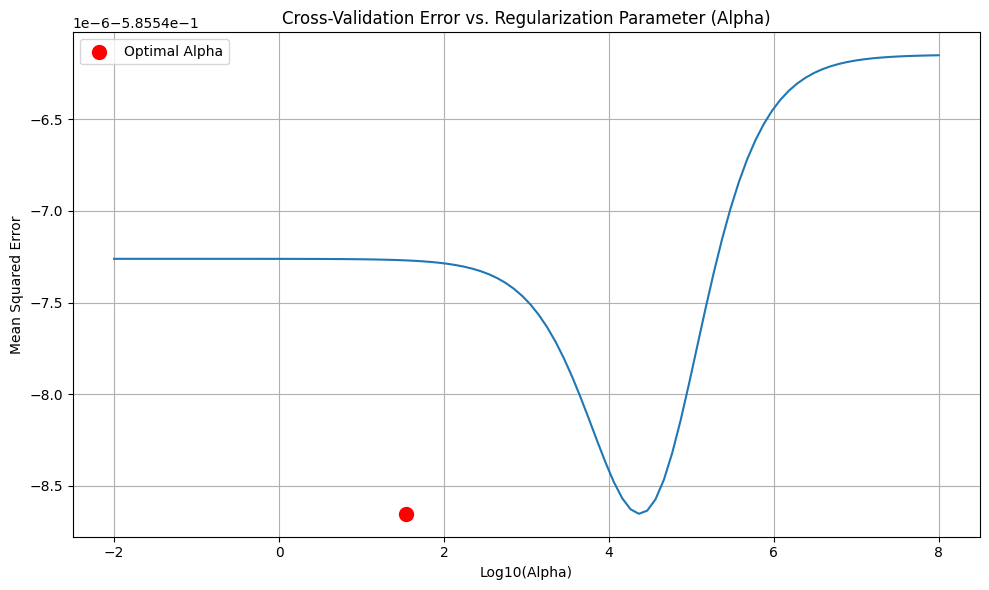

In [28]:
import matplotlib.pyplot as plt

# Get the mean cross-validated errors for each alpha
# For RidgeCV, when store_cv_results=True, cv_results_ directly holds the scores
# for each alpha across folds/samples. We need to average them.
mse_per_alpha = -ridge_cv.cv_results_.mean(axis=0)

# Plot the mean squared error as a function of alpha (lambda)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(ridge_cv.alphas), mse_per_alpha)
ax.scatter(np.log10(ridge_cv.alpha_), min(mse_per_alpha), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Cross-Validation Error vs. Regularization Parameter (Alpha)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
optimal_alpha_ridge = ridge_cv.alpha_
optimal_ridge_model = skl.Ridge(alpha=optimal_alpha_ridge)
optimal_ridge_model.fit(Xs, y)

# Get the coefficients and feature names
ridge_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_ridge_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Ridge Regression Coefficients (alpha={optimal_alpha_ridge:.4f}):")
display(ridge_coefficients)

Optimal Ridge Regression Coefficients (alpha=34.3047):


,Feature,Coefficient
9,Have you ever had suicidal thoughts ?[Yes],0.183698
1,Academic Pressure,0.149962
11,Financial Stress,0.099996
8,Dietary Habits[Unhealthy],0.063554
10,Work/Study Hours,0.052281
7,Dietary Habits[Moderate],0.029429
5,Sleep Duration[Less than 5 hours],0.018459
12,Family History of Mental Illness[Yes],0.014273
2,CGPA,0.010286
4,Sleep Duration[7-8 hours],0.001976


<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2922/3750770349.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Log($\lambda$)')


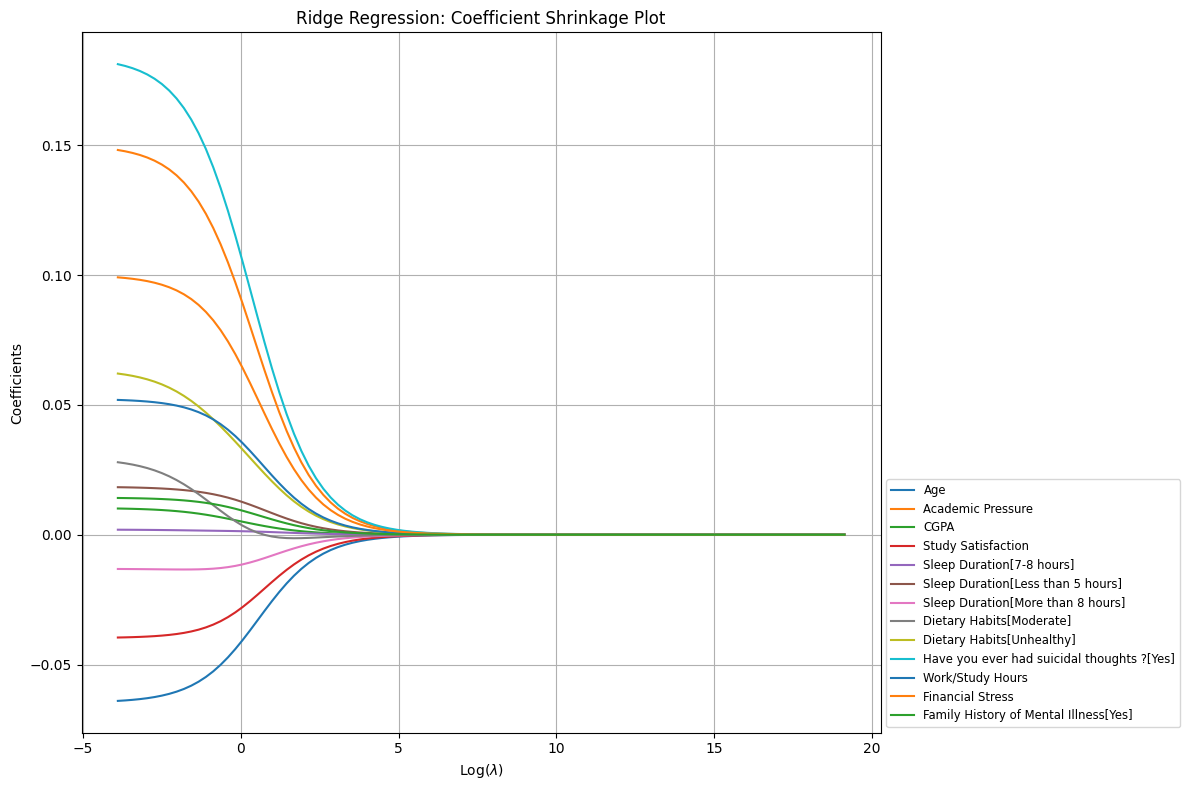

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure Xs.columns is available for labels
feature_names = Xs.columns if hasattr(Xs, 'columns') else [f'Feature {i}' for i in range(Xs.shape[1])]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each coefficient against log(lambda)
for i in range(soln_array.shape[0]):
    ax.plot(np.log(lambdas), soln_array[i], label=feature_names[i])

ax.set_xlabel('Log($\lambda$)')
ax.set_ylabel('Coefficients')
ax.set_title('Ridge Regression: Coefficient Shrinkage Plot')
ax.legend(loc='lower left', bbox_to_anchor=(1,0), ncol=1, fontsize='small') # Place legend outside for clarity
ax.grid(True)
plt.tight_layout()
plt.show()

# Lasso Regression

In [31]:
from sklearn.linear_model import LassoCV

# Define a range of alpha values for LassoCV to search over.
# `n_alphas` specifies the number of alphas along the regularization path.
# `cv` specifies the cross-validation splitting strategy.
# `random_state` for reproducibility.
lasso_cv = LassoCV(alphas=None, cv=10, random_state=42, n_jobs=-1, max_iter=10000)

# Fit the model to the scaled features and target variable
lasso_cv.fit(Xs, y)

# Display the optimal alpha (regularization parameter)
print(f"Optimal regularization parameter (alpha) for Lasso: {lasso_cv.alpha_:.4f}")

Optimal regularization parameter (alpha) for Lasso: 0.0003


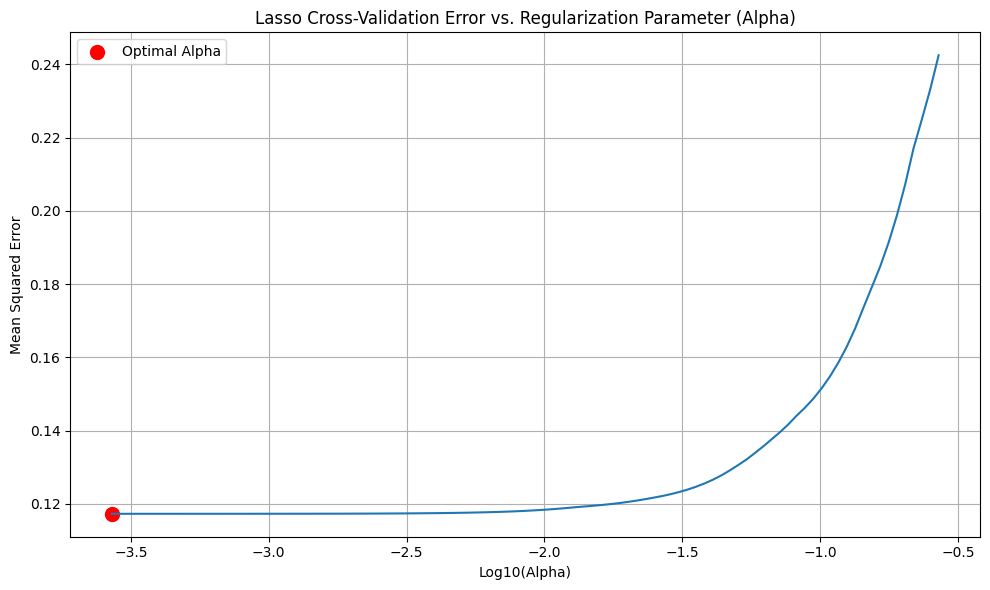

In [32]:
import matplotlib.pyplot as plt

# Get the mean cross-validated errors for each alpha
mse_per_alpha_lasso = lasso_cv.mse_path_.mean(axis=1)

# Plot the mean squared error as a function of alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(lasso_cv.alphas_), mse_per_alpha_lasso)
ax.scatter(np.log10(lasso_cv.alpha_), min(mse_per_alpha_lasso), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Lasso Cross-Validation Error vs. Regularization Parameter (Alpha)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
optimal_alpha_lasso = lasso_cv.alpha_
optimal_lasso_model = skl.Lasso(alpha=optimal_alpha_lasso)
optimal_lasso_model.fit(Xs, y)

# Get the coefficients and feature names
lasso_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_lasso_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Lasso Regression Coefficients (alpha={optimal_alpha_lasso:.4f}):")
display(lasso_coefficients[lasso_coefficients['Coefficient'] != 0]) # Display only non-zero coefficients

Optimal Lasso Regression Coefficients (alpha=0.0003):


,Feature,Coefficient
9,Have you ever had suicidal thoughts ?[Yes],0.183803
1,Academic Pressure,0.149957
11,Financial Stress,0.099904
8,Dietary Habits[Unhealthy],0.063103
10,Work/Study Hours,0.052106
7,Dietary Habits[Moderate],0.028928
5,Sleep Duration[Less than 5 hours],0.018039
12,Family History of Mental Illness[Yes],0.014024
2,CGPA,0.010039
4,Sleep Duration[7-8 hours],0.001540


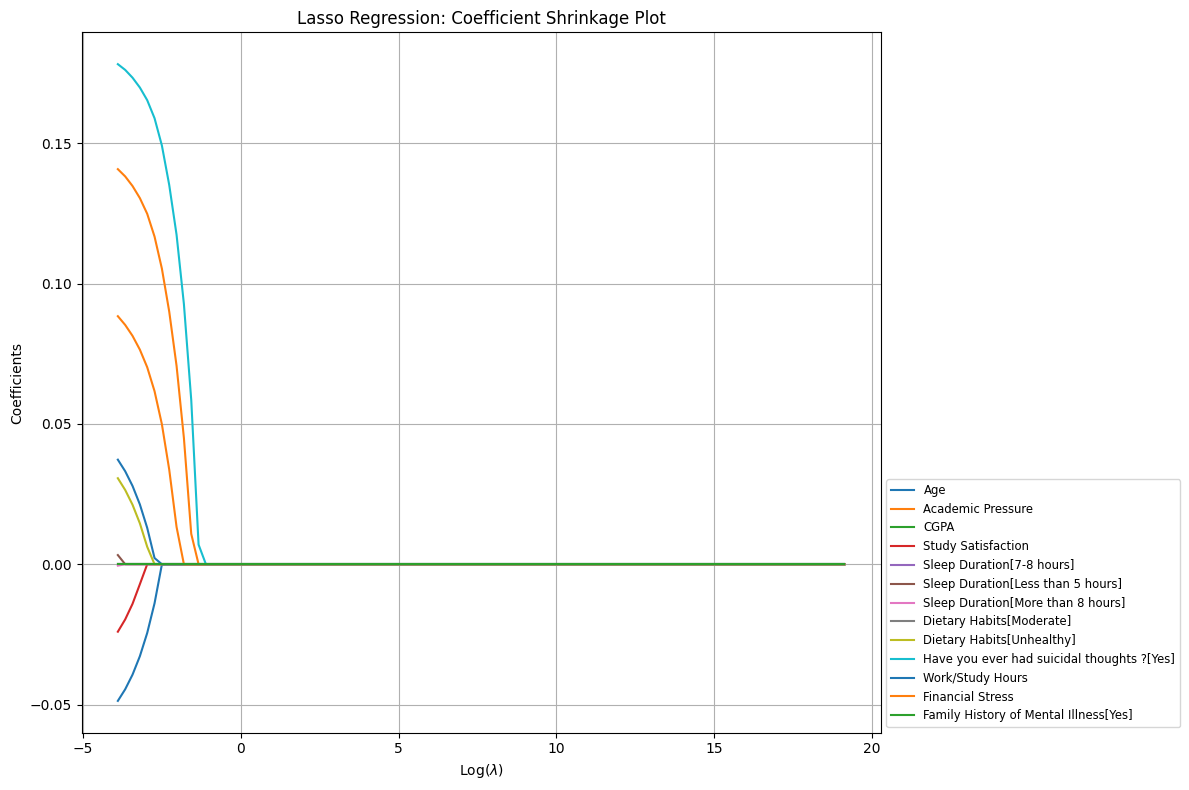

In [34]:
import sklearn.linear_model as skl
import numpy as np
import matplotlib.pyplot as plt

# Reuse Xs, y, and lambdas from previous steps
# Xs = X.drop(columns=['intercept'])
# Xs = (Xs - Xs.mean(0).to_numpy()[None,:]) / Xs.std(0).to_numpy()[None,:]
# lambdas = 10**np.linspace(8, -2, 100) / y.std()

# Compute the Lasso regularization path (l1_ratio=1.0 for Lasso)
soln_array_lasso = skl.ElasticNet.path(Xs,
                                      y,
                                      l1_ratio=1., # 1.0 for Lasso
                                      alphas=lambdas
                                      )[1]

# Ensure feature_names is available
feature_names = Xs.columns if hasattr(Xs, 'columns') else [f'Feature {i}' for i in range(Xs.shape[1])]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each coefficient against log(lambda)
for i in range(soln_array_lasso.shape[0]):
    ax.plot(np.log(lambdas), soln_array_lasso[i], label=feature_names[i])

ax.set_xlabel(r'Log($\lambda$)')
ax.set_ylabel('Coefficients')
ax.set_title('Lasso Regression: Coefficient Shrinkage Plot')
ax.legend(loc='lower left', bbox_to_anchor=(1,0), ncol=1, fontsize='small') # Place legend outside for clarity
ax.grid(True)
plt.tight_layout()
plt.show()

# Elastic Net Regression

In [35]:
from sklearn.linear_model import ElasticNetCV

# Define a range of l1_ratio values to search over (0 for Ridge, 1 for Lasso)
l1_ratios = np.linspace(0.01, 1.0, 10)

# Initialize ElasticNetCV model. `alphas=None` means it will automatically choose a grid.
elastic_net_cv = ElasticNetCV(l1_ratio=l1_ratios,
                              cv=10,
                              random_state=42,
                              n_jobs=-1,
                              max_iter=10000)

# Fit the model to the scaled features and target variable
elastic_net_cv.fit(Xs, y)

# Display the optimal alpha and l1_ratio
print(f"Optimal alpha for Elastic Net: {elastic_net_cv.alpha_:.4f}")
print(f"Optimal l1_ratio for Elastic Net: {elastic_net_cv.l1_ratio_:.4f}")

Optimal alpha for Elastic Net: 0.0003
Optimal l1_ratio for Elastic Net: 1.0000


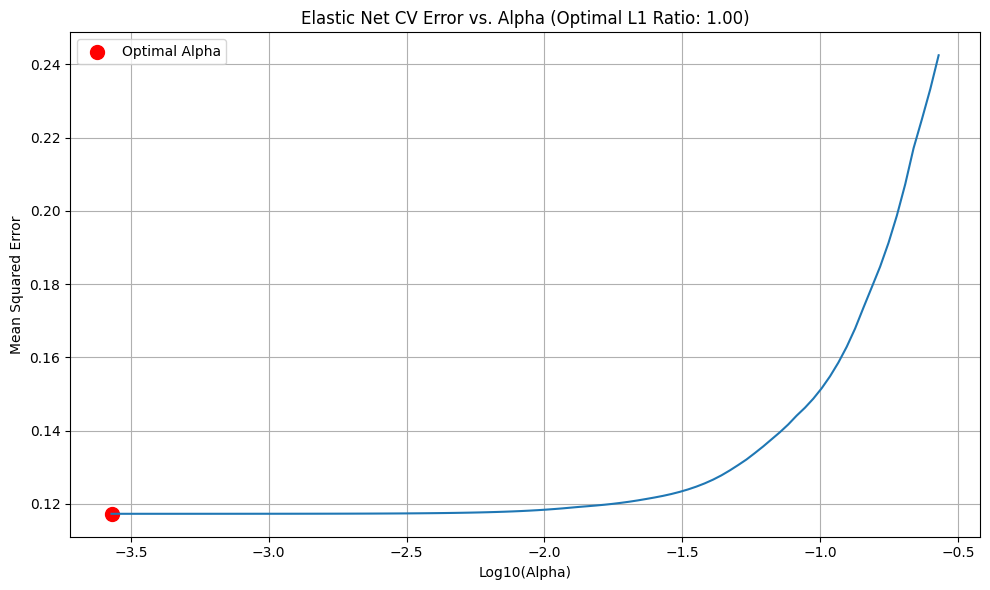

In [36]:
import matplotlib.pyplot as plt

# Get the index of the optimal l1_ratio
optimal_l1_ratio_idx = np.argmin(np.abs(elastic_net_cv.l1_ratio - elastic_net_cv.l1_ratio_))

# Extract the mean cross-validated errors for the optimal l1_ratio
mse_per_alpha_elastic_net = elastic_net_cv.mse_path_[optimal_l1_ratio_idx, :].mean(axis=1)

# Get the alphas corresponding to the optimal l1_ratio
alphas_for_plotting = elastic_net_cv.alphas_[optimal_l1_ratio_idx]

# Plot the mean squared error as a function of alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(alphas_for_plotting), mse_per_alpha_elastic_net)
ax.scatter(np.log10(elastic_net_cv.alpha_), min(mse_per_alpha_elastic_net), color='red', s=100, label='Optimal Alpha')
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('Mean Squared Error')
ax.set_title(f'Elastic Net CV Error vs. Alpha (Optimal L1 Ratio: {elastic_net_cv.l1_ratio_:.2f})')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
import sklearn.linear_model as skl

optimal_alpha_elastic_net = elastic_net_cv.alpha_
optimal_l1_ratio_elastic_net = elastic_net_cv.l1_ratio_

optimal_elastic_net_model = skl.ElasticNet(alpha=optimal_alpha_elastic_net,
                                           l1_ratio=optimal_l1_ratio_elastic_net,
                                           max_iter=10000)
optimal_elastic_net_model.fit(Xs, y)

# Get the coefficients and feature names
elastic_net_coefficients = pd.DataFrame({
    'Feature': Xs.columns,
    'Coefficient': optimal_elastic_net_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Optimal Elastic Net Regression Coefficients (alpha={optimal_alpha_elastic_net:.4f}, l1_ratio={optimal_l1_ratio_elastic_net:.4f}):")
display(elastic_net_coefficients[elastic_net_coefficients['Coefficient'] != 0]) # Display only non-zero coefficients

Optimal Elastic Net Regression Coefficients (alpha=0.0003, l1_ratio=1.0000):


,Feature,Coefficient
9,Have you ever had suicidal thoughts ?[Yes],0.183803
1,Academic Pressure,0.149957
11,Financial Stress,0.099904
8,Dietary Habits[Unhealthy],0.063103
10,Work/Study Hours,0.052106
7,Dietary Habits[Moderate],0.028928
5,Sleep Duration[Less than 5 hours],0.018039
12,Family History of Mental Illness[Yes],0.014024
2,CGPA,0.010039
4,Sleep Duration[7-8 hours],0.001540


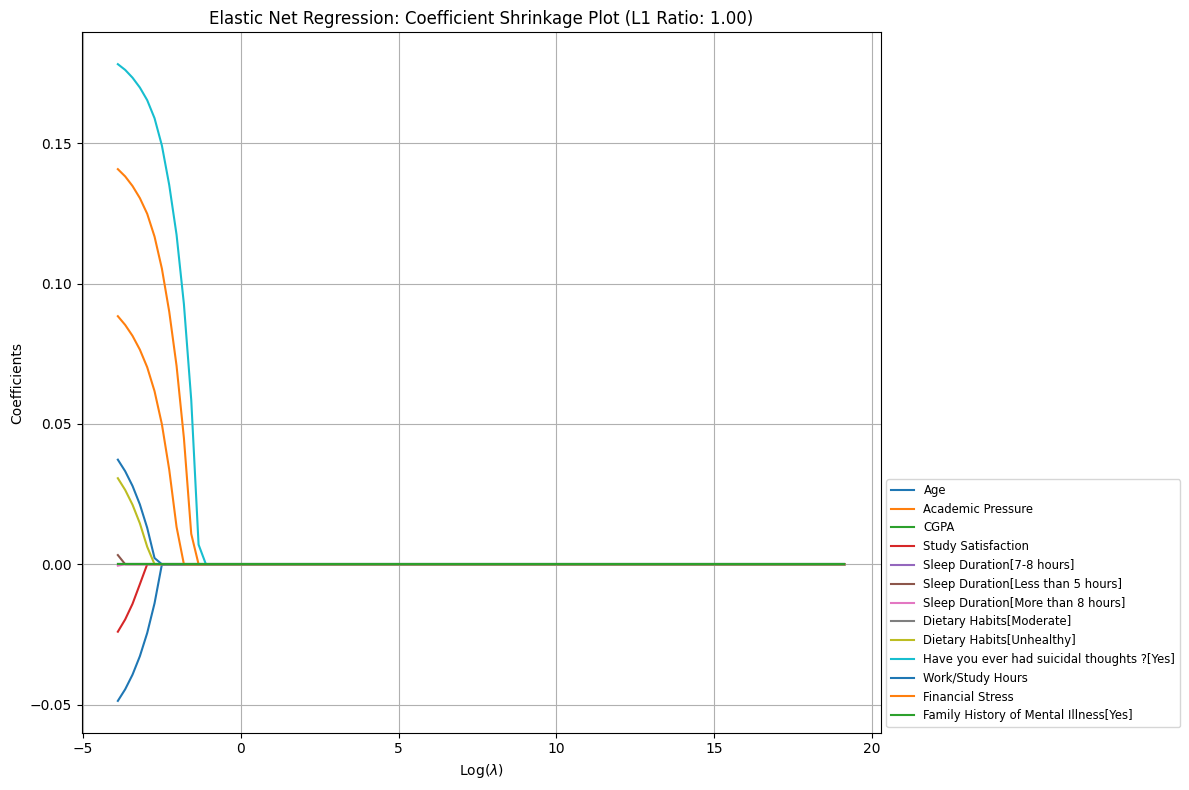

In [38]:
import sklearn.linear_model as skl
import numpy as np
import matplotlib.pyplot as plt

# Get the optimal l1_ratio from the ElasticNetCV result
optimal_l1_ratio_elastic_net = elastic_net_cv.l1_ratio_

# Compute the Elastic Net regularization path
soln_array_elastic_net = skl.ElasticNet.path(Xs,
                                              y,
                                              l1_ratio=optimal_l1_ratio_elastic_net,
                                              alphas=lambdas
                                             )[1]

# Ensure feature_names is available
feature_names = Xs.columns if hasattr(Xs, 'columns') else [f'Feature {i}' for i in range(Xs.shape[1])]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each coefficient against log(lambda)
for i in range(soln_array_elastic_net.shape[0]):
    ax.plot(np.log(lambdas), soln_array_elastic_net[i], label=feature_names[i])

ax.set_xlabel(r'Log($\lambda$)')
ax.set_ylabel('Coefficients')
ax.set_title(f'Elastic Net Regression: Coefficient Shrinkage Plot (L1 Ratio: {optimal_l1_ratio_elastic_net:.2f})')
ax.legend(loc='lower left', bbox_to_anchor=(1,0), ncol=1, fontsize='small') # Place legend outside for clarity
ax.grid(True)
plt.tight_layout()
plt.show()

# Comparison of Model Coefficients

In [44]:
import pandas as pd

# Reuse the individual coefficient DataFrames created for the comparison plot
# ols_coef_df_for_plot, ridge_coef_df_for_plot, lasso_coef_df_for_plot, elastic_net_coef_df_for_plot

# Rename 'Coefficient' column in each to reflect the model
ols_coefficients_renamed = ols_coef_df_for_plot.rename(columns={'Coefficient': 'OLS_Coefficient'}).drop(columns=['Model'])
ridge_coefficients_renamed = ridge_coef_df_for_plot.rename(columns={'Coefficient': 'Ridge_Coefficient'}).drop(columns=['Model'])
lasso_coefficients_renamed = lasso_coef_df_for_plot.rename(columns={'Coefficient': 'Lasso_Coefficient'}).drop(columns=['Model'])
elastic_net_coefficients_renamed = elastic_net_coef_df_for_plot.rename(columns={'Coefficient': 'ElasticNet_Coefficient'}).drop(columns=['Model'])

# Merge them all on 'Feature'
combined_coefficients = pd.merge(ols_coefficients_renamed, ridge_coefficients_renamed, on='Feature', how='outer')
combined_coefficients = pd.merge(combined_coefficients, lasso_coefficients_renamed, on='Feature', how='outer')
combined_coefficients = pd.merge(combined_coefficients, elastic_net_coefficients_renamed, on='Feature', how='outer')

# Sort by OLS_Coefficient for better readability
combined_coefficients = combined_coefficients.sort_values(by='OLS_Coefficient', ascending=False)

print("Comparison of Coefficients Across All Models:")
display(combined_coefficients)

Comparison of Coefficients Across All Models:


,Feature,OLS_Coefficient,Ridge_Coefficient,Lasso_Coefficient,ElasticNet_Coefficient
7,Have you ever had suicidal thoughts ?[Yes],0.381418,0.183698,0.183803,0.183803
4,Dietary Habits[Unhealthy],0.131851,0.063554,0.063103,0.063103
0,Academic Pressure,0.108627,0.149962,0.149957,0.149957
6,Financial Stress,0.069614,0.099996,0.099904,0.099904
3,Dietary Habits[Moderate],0.061686,0.029429,0.028928,0.028928
9,Sleep Duration[Less than 5 hours],0.040383,0.018459,0.018039,0.018039
5,Family History of Mental Illness[Yes],0.028577,0.014273,0.014024,0.014024
12,Work/Study Hours,0.014109,0.052281,0.052106,0.052106
2,CGPA,0.007003,0.010286,0.010039,0.010039
8,Sleep Duration[7-8 hours],0.004493,0.001976,0.001540,0.001540


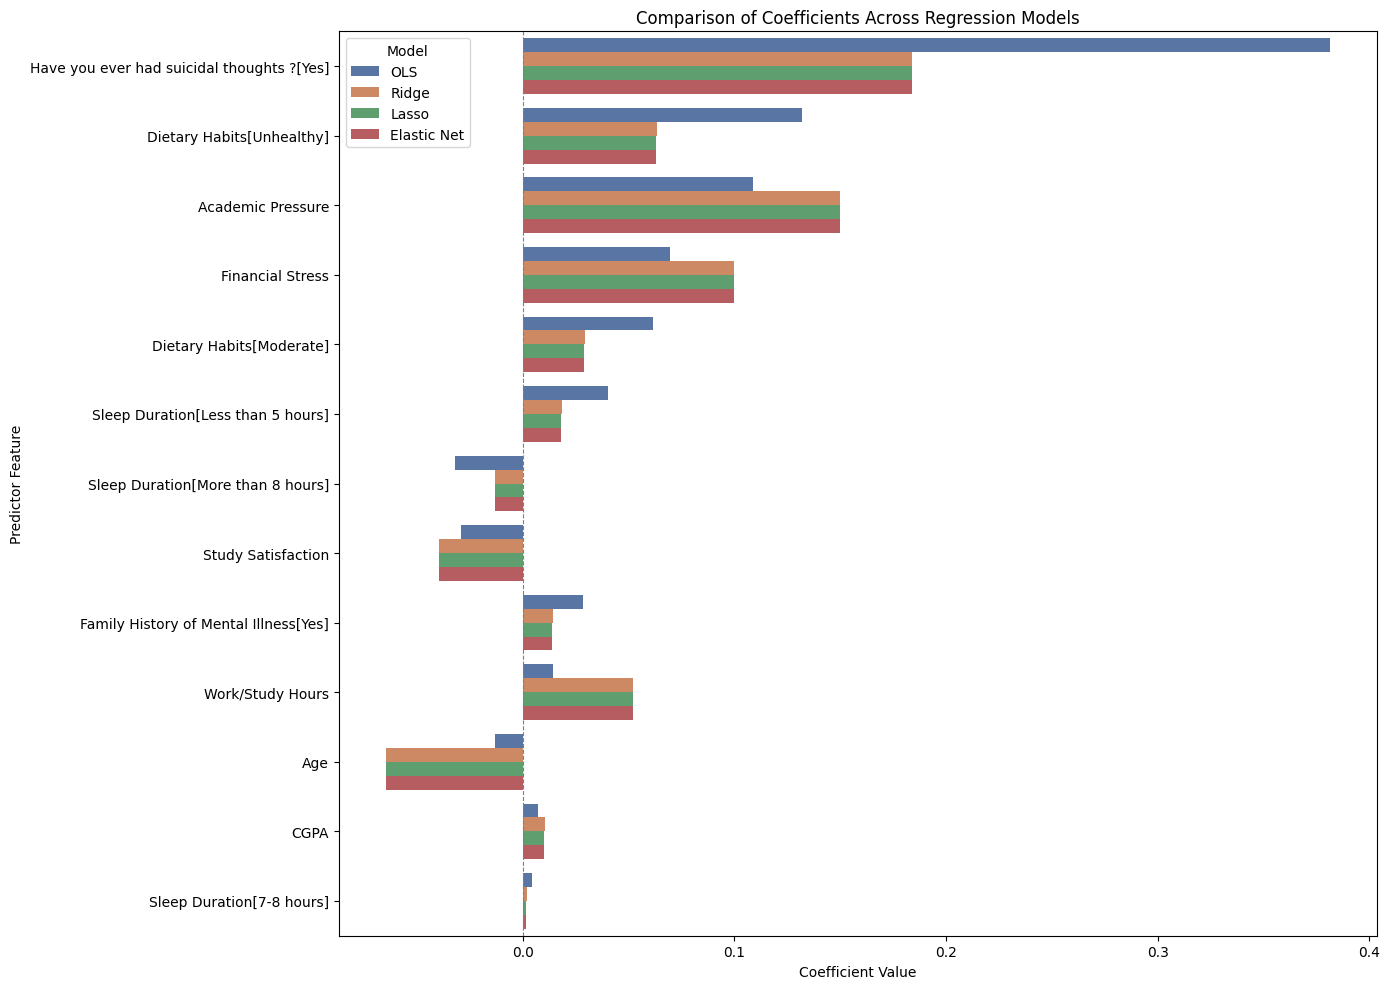

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare OLS coefficients (excluding intercept and aligning with scaled features)
ols_coefs_aligned = results.params[X_for_elasticnet.columns]
ols_coef_df_for_plot = pd.DataFrame({
    'Feature': ols_coefs_aligned.index,
    'Coefficient': ols_coefs_aligned.values,
    'Model': 'OLS'
})

# Prepare Ridge coefficients
ridge_coef_df_for_plot = pd.DataFrame({
    'Feature': ridge_coefficients['Feature'],
    'Coefficient': ridge_coefficients['Coefficient'],
    'Model': 'Ridge'
})

# Prepare Lasso coefficients
lasso_coef_df_for_plot = pd.DataFrame({
    'Feature': lasso_coefficients['Feature'],
    'Coefficient': lasso_coefficients['Coefficient'],
    'Model': 'Lasso'
})

# Prepare Elastic Net coefficients
elastic_net_coef_df_for_plot = pd.DataFrame({
    'Feature': elastic_net_coefficients['Feature'],
    'Coefficient': elastic_net_coefficients['Coefficient'],
    'Model': 'Elastic Net'
})

# Combine all coefficient DataFrames
all_coefs_df = pd.concat([
    ols_coef_df_for_plot,
    ridge_coef_df_for_plot,
    lasso_coef_df_for_plot,
    elastic_net_coef_df_for_plot
])

# Sort by absolute OLS coefficient for better visualization of importance
sorted_features = ols_coef_df_for_plot.reindex(ols_coef_df_for_plot['Coefficient'].abs().sort_values(ascending=False).index)['Feature']

fig, ax = plt.subplots(figsize=(14, 10))
sns.barplot(x='Coefficient', y='Feature', hue='Model', data=all_coefs_df, palette='deep', order=sorted_features, ax=ax)

ax.set_title('Comparison of Coefficients Across Regression Models')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Predictor Feature')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.legend(title='Model')
plt.tight_layout()
plt.show()

In [46]:
N_obs = len(y)

# Calculate BIC for OLS
ols_bic = N_obs * np.log(ols_mse) + (results.df_model + 1) * np.log(N_obs) # +1 for intercept

# Calculate BIC for Ridge
ridge_bic = N_obs * np.log(ridge_mse) + Xs.shape[1] * np.log(N_obs)

# Calculate BIC for Lasso
lasso_bic = N_obs * np.log(lasso_mse) + lasso_non_zero_coef * np.log(N_obs)

# Calculate BIC for Elastic Net
elastic_net_bic = N_obs * np.log(elastic_net_mse) + elastic_net_non_zero_coef * np.log(N_obs)

# Calculate AIC for OLS
ols_aic = N_obs * np.log(ols_mse) + 2 * (results.df_model + 1)

# Calculate AIC for Ridge
ridge_aic = N_obs * np.log(ridge_mse) + 2 * Xs.shape[1]

# Calculate AIC for Lasso
lasso_aic = N_obs * np.log(lasso_mse) + 2 * lasso_non_zero_coef

# Calculate AIC for Elastic Net
elastic_net_aic = N_obs * np.log(elastic_net_mse) + 2 * elastic_net_non_zero_coef

# Calculate Mallows' Cp
s_sq = results.mse_resid # Estimate of error variance from the full OLS model

# OLS Cp
ols_sse = ols_mse * N_obs
ols_p = results.df_model + 1
ols_cp = (ols_sse / s_sq) - N_obs + 2 * ols_p

# Ridge Cp
ridge_sse = ridge_mse * N_obs
ridge_p = Xs.shape[1] # Number of predictors
ridge_cp = (ridge_sse / s_sq) - N_obs + 2 * ridge_p

# Lasso Cp
lasso_sse = lasso_mse * N_obs
lasso_p = lasso_non_zero_coef # Number of non-zero coefficients
lasso_cp = (lasso_sse / s_sq) - N_obs + 2 * lasso_p

# Elastic Net Cp
elastic_net_sse = elastic_net_mse * N_obs
elastic_net_p = elastic_net_non_zero_coef # Number of non-zero coefficients
elastic_net_cp = (elastic_net_sse / s_sq) - N_obs + 2 * elastic_net_p


# Add BIC and AIC to the performance_metrics DataFrame
performance_metrics.loc['OLS', 'BIC'] = ols_bic
performance_metrics.loc['Ridge', 'BIC'] = ridge_bic
performance_metrics.loc['Lasso', 'BIC'] = lasso_bic
performance_metrics.loc['Elastic Net', 'BIC'] = elastic_net_bic

performance_metrics.loc['OLS', 'AIC'] = ols_aic
performance_metrics.loc['Ridge', 'AIC'] = ridge_aic
performance_metrics.loc['Lasso', 'AIC'] = lasso_aic
performance_metrics.loc['Elastic Net', 'AIC'] = elastic_net_aic

performance_metrics.loc['OLS', 'Cp'] = ols_cp
performance_metrics.loc['Ridge', 'Cp'] = ridge_cp
performance_metrics.loc['Lasso', 'Cp'] = lasso_cp
performance_metrics.loc['Elastic Net', 'Cp'] = elastic_net_cp

print("Model Performance Metrics with BIC, AIC, and Cp:")
display(performance_metrics.round(4).sort_values(by='BIC'))

Model Performance Metrics with BIC, AIC, and Cp:


,R-squared,Adjusted R-squared,MSE,RMSE,MAE,BIC,AIC,Cp
Model,,,,,,,,
Ridge,0.5174,0.5171,0.1171,0.3422,0.268,-59629.1276,-59736.1857,12.0200
Lasso,0.5173,0.5171,0.1171,0.3422,0.268,-59628.9271,-59735.9852,12.2204
Elastic Net,0.5173,0.5171,0.1171,0.3422,0.268,-59628.9271,-59735.9852,12.2204
OLS,0.5174,0.5171,0.1171,0.3422,0.268,-59618.9124,-59734.2057,14.0000
